# Time Alignment and Linear Time Normalization (LTN)

Demonstrate **Linear Time Normalization (LTN)** for aligning two
speech-like sequences of the *same word* spoken at different speeds.

We will:
1. Plot the original signals and observe their differences.
2. Perform Linear Time Normalization on the longer signal (Signal 2).
3. Compare the reference signal with the normalized signal.
4. Visualize the **alignment path** between sample indices.
5. Write an inference on how LTN helps align temporal patterns.


In [1]:
"""Import the required libraries and define the input signals.

Signal 1: Reference speech sequence (shorter, faster utterance)
Signal 2: Test speech sequence (longer, slower utterance)
"""
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

# Given signals
signal1 = np.array([0.2, 0.4, 0.6, 0.8, 1.0, 0.8, 0.6, 0.4, 0.2], dtype=float)  # length 9
signal2 = np.array([0.2, 0.3, 0.5, 0.7, 0.9, 1.0, 0.9, 0.7, 0.5, 0.4, 0.3, 0.2], dtype=float)  # length 12

len1 = len(signal1)
len2 = len(signal2)

print(f"Length of Signal 1 (reference): {len1}")
print(f"Length of Signal 2 (test): {len2}")


Length of Signal 1 (reference): 9
Length of Signal 2 (test): 12


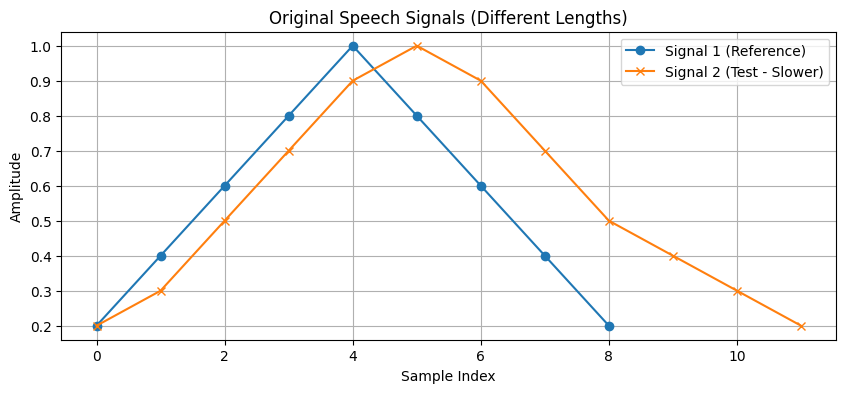

In [2]:
"""Plot the two original speech signals.

- Signal 1 is shorter (fewer samples).
- Signal 2 is longer (same word spoken more slowly).
"""
# Time (sample index) for each signal
t1 = np.arange(len1)
t2 = np.arange(len2)

plt.figure(figsize=(10, 4))
plt.plot(t1, signal1, marker='o')
plt.plot(t2, signal2, marker='x')
plt.title('Original Speech Signals (Different Lengths)')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')
plt.legend(['Signal 1 (Reference)', 'Signal 2 (Test - Slower)'])
plt.grid(True)
plt.show()


Original Signal 2 length: 12
LTN-normalized Signal 2 length: 9


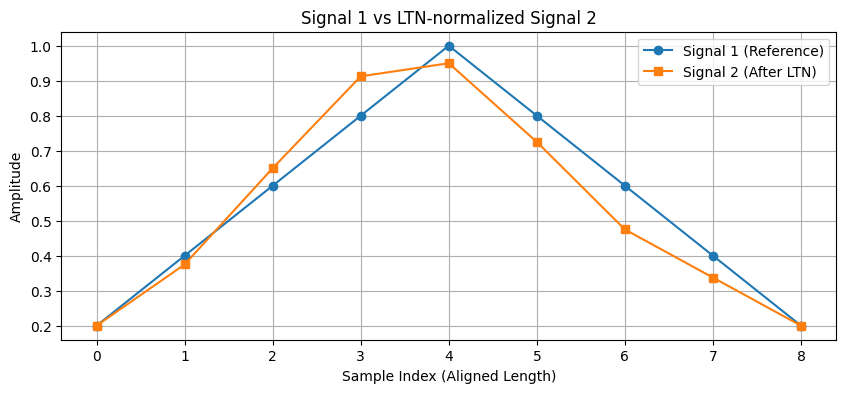

MSE before LTN (using first 9 samples of Signal 2): 0.038889
MSE after LTN (using normalized Signal 2): 0.004826


In [3]:
"""Perform Linear Time Normalization (LTN) on Signal 2.

Idea:
- Treat each signal as if it is sampled over a *time axis* from 0 to 1.
- Resample (interpolate) Signal 2 so that it has the same number
  of samples as Signal 1.
- This is equivalent to compressing/stretching Signal 2 in time.
"""
# Normalized time axes from 0 to 1
t1_norm = np.linspace(0, 1, len1)           # reference grid
t2_norm = np.linspace(0, 1, len2)           # original test grid

# Interpolate Signal 2 onto the time axis of Signal 1
signal2_ltn = np.interp(t1_norm, t2_norm, signal2)

print("Original Signal 2 length:", len2)
print("LTN-normalized Signal 2 length:", len(signal2_ltn))

# Plot the reference and LTN-normalized signals
plt.figure(figsize=(10, 4))
plt.plot(t1, signal1, marker='o')
plt.plot(t1, signal2_ltn, marker='s')
plt.title('Signal 1 vs LTN-normalized Signal 2')
plt.xlabel('Sample Index (Aligned Length)')
plt.ylabel('Amplitude')
plt.legend(['Signal 1 (Reference)', 'Signal 2 (After LTN)'])
plt.grid(True)
plt.show()

# Compute a simple error measure (Mean Squared Error) before and after LTN
# For "before", compare only the first len1 samples of Signal 2
mse_before = np.mean((signal1 - signal2[:len1]) ** 2)
mse_after = np.mean((signal1 - signal2_ltn) ** 2)

print(f"MSE before LTN (using first {len1} samples of Signal 2): {mse_before:.6f}")
print(f"MSE after LTN (using normalized Signal 2): {mse_after:.6f}")


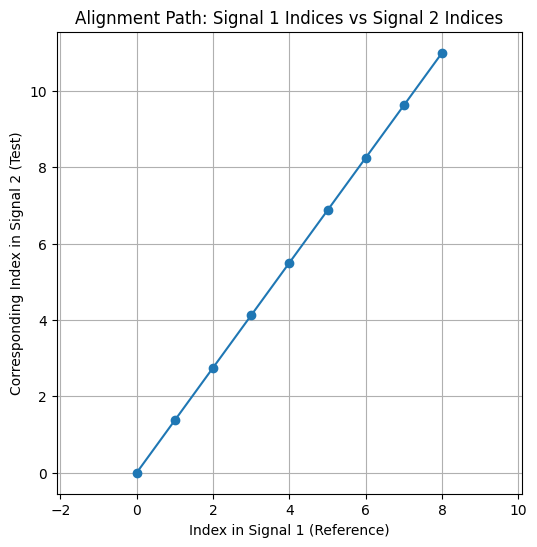

In [4]:
"""Plot the alignment path between sample indices.

For Linear Time Normalization, the mapping from Signal 1 indices (i)
to original Signal 2 indices (j) is approximately linear:

    j = i * (len2 - 1) / (len1 - 1)

We visualize this mapping as a straight line in the (i, j) plane.
"""
# Index-based alignment mapping (from LTN)
i_indices = np.arange(len1)                 # indices in Signal 1
j_mapped = i_indices * (len2 - 1) / (len1 - 1)  # fractional indices in original Signal 2

plt.figure(figsize=(6, 6))
plt.plot(i_indices, j_mapped, marker='o')
plt.title('Alignment Path: Signal 1 Indices vs Signal 2 Indices')
plt.xlabel('Index in Signal 1 (Reference)')
plt.ylabel('Corresponding Index in Signal 2 (Test)')
plt.grid(True)
plt.axis('equal')  # to emphasize the near-linear relationship
plt.show()


## Inference

- **Signal 2** is longer than **Signal 1**, representing a slower pronunciation
  of the same word.
- Using **Linear Time Normalization**, we *compress* Signal 2 along the time axis so
  that it has the **same number of samples** as Signal 1.
- After LTN, the overall shape and peaks of the normalized Signal 2 closely follow
  those of Signal 1, which is reflected in a **reduced Mean Squared Error (MSE)**.
- The alignment path between sample indices is almost a **straight line**, showing
  that each sample in Signal 1 corresponds to a proportionally located sample in
  the original Signal 2.
- This demonstrates that LTN allows us to **compare and align temporal patterns**
  even when the same word is spoken at different speeds, by normalizing the time
  duration of the signals.
